# Análise Exploratória de Dados - Credit Card Fraud Detection
**Autor**: Gustavo Duarte Amorim

**AI Co-authored**: Este notebook contém código gerado por IA (Gemini 3.0 Flash).

Este colab conduz uma análise exploratória do dataset [Credit Card Fraud Detection, (Kaggle - 2018)](https://www.kaggle.com/datasetsa/mlg-ulb/creditcardfraud), e faz parte do processo de AGEMC realizado por estudantes da Universidade Federal de Goiás para a disciplina de Pensamento Analítico de Dados.

O objetivo dessa análise é responder a pergunta: "É possível detectar transações fraudulentas em cartões de crédito com alta precisão, mesmo diante de um conjunto de dados extremamente desbalanceado?"

Para isso, vamos explorar os dados, entender como o dataset está estruturado e realizar uma preparação inicial dos dados para modelá-los posteriormente.


## 0. Importando o dataset via Kaggle

In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


## 1. Inspeção Inicial e Limpeza de Dados

Nesta etapa, realizaremos uma auditoria inicial no conjunto de dados para garantir a qualidade da análise.

### 1.1. Integridade e Tipos de Dados

Vamos analisar a integridade dos dados (verificar se existem valores nulos ou duplicatas) e tratarmos os dados para trabalharmos com eles.

In [29]:
import pandas as pd
import os
from sklearn.preprocessing import RobustScaler

# 1.1. Integridade e Carregamento
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)
df = pd.read_csv(full_path)

print("### 1.1. Integridade e Tipos de Dados")
print(f"\nFormato inicial: {df.shape}")
print("\n--- Valores Nulos ---")
print(df.isnull().sum().sum())

duplicados = df.duplicated().sum()
print(f"\n--- Duplicatas: {duplicados} ---")
df = df.drop_duplicates() if duplicados > 0 else df

print(f"Formato após limpeza: {df.shape}")
print("Colunas atuais:", df.columns.tolist())
display(df.head())

### 1.1. Integridade e Tipos de Dados

Formato inicial: (284807, 31)

--- Valores Nulos ---
0

--- Duplicatas: 1081 ---
Formato após limpeza: (283726, 31)
Colunas atuais: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 1.2 Distribuição das Classes

Visualizando como o dataset está distribuído (entre transações classificadas como fraude ou transação legítima)

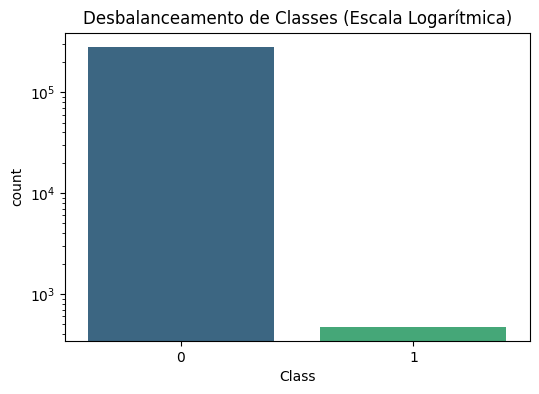

Proporção das classes (0: Legítima, 1: Fraude):
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


In [30]:
plt.figure(figsize=(6, 4))
# Usando hue para evitar o aviso de depreciação do Seaborn
sns.countplot(x='Class', data=df, hue='Class', palette='viridis', legend=False)
plt.title('Desbalanceamento de Classes (Escala Logarítmica)')
plt.yscale('log')
plt.show()

print("Proporção das classes (0: Legítima, 1: Fraude):")
print(df['Class'].value_counts(normalize=True))

**Análise**: Nesse gráfico é possível visualizar que o dataset está extremamente desbalanceado, possuindo muito mais transações legítimas do que fraudulentas. O insight retirado daqui é que precisaremos trabalhar em cima desse desbalanceamento para garantir que um modelo possa predizer corretamente quais são as transações fraudulentas.

### 1.3. Normalização dos dados

Nesta etapa, vamos preparar os dados para o treinamento, focando na escala da variável `Amount`.

**Por que normalizar o 'Amount'?**
As variáveis de `V1` a `V28` são o resultado de uma transformação PCA, o que significa que elas já estão em uma escala reduzida e similar entre si. Já a variável `Amount` (valor da transação) preserva sua escala original, com valores que podem variar de 0 a milhares de euros.

Algoritmos baseados em distância ou gradiente (como SVM, KNN ou Redes Neurais) e até mesmo modelos de árvore podem ter sua convergência prejudicada ou atribuir importância desproporcional a features com magnitudes maiores. Normalizar o `Amount` coloca todos os atributos em um espaço matemático comparável, melhorando a estabilidade e a performance do modelo.

In [31]:
# Escalonamento para fins de visualização.
if 'Amount' in df.columns:
    rs = RobustScaler()
    df['scaled_amount'] = rs.fit_transform(df['Amount'].values.reshape(-1,1))

    if 'Amount' in df.columns:
        df.drop('Amount', axis=1, inplace=True)

    # Reorganiza para colocar o valor escalonado no início
    scaled_amount = df['scaled_amount']
    df.drop(['scaled_amount'], axis=1, inplace=True)
    df.insert(0, 'scaled_amount', scaled_amount)

print(f"Formato após normalização: {df.shape}")
print("Colunas atuais:", df.columns.tolist())
display(df.head())

Formato após normalização: (283726, 31)
Colunas atuais: ['scaled_amount', 'Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class']


,scaled_amount,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.774718,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.268530,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.959811,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.411487,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.667362,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


### 1.4. Calculando correlação apenas com a variável alvo para simplificar

Nessa etapa, calculamos a correlação entre as features do dataset e a variável alvo para identificar quais contribuem mais para identificar ou não uma fraude

Correlação das Variáveis


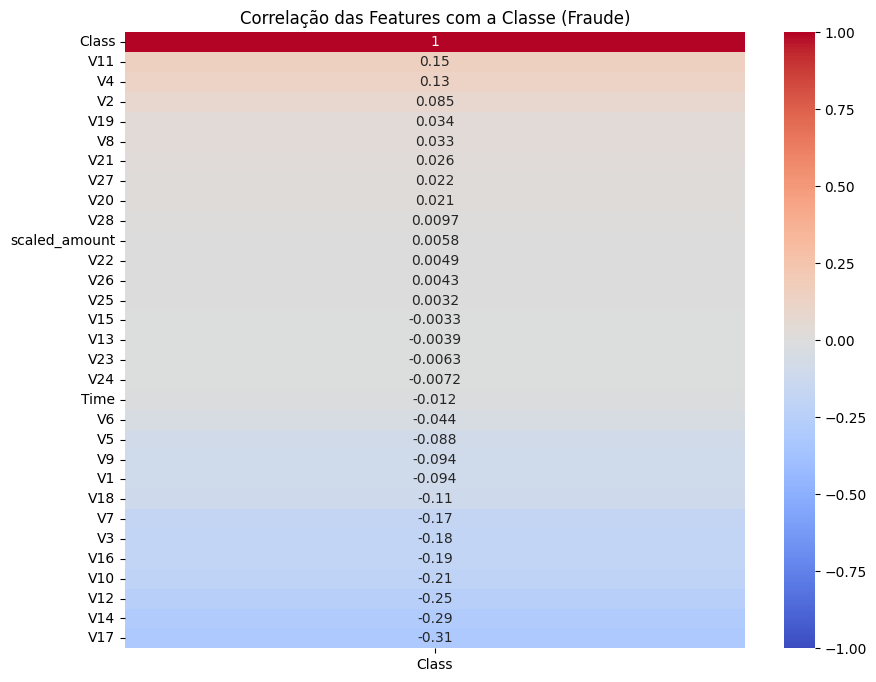

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Correlação das Variáveis")
plt.figure(figsize=(10, 8))

corr = df.corr()
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação das Features com a Classe (Fraude)')
plt.show()

## 2. Análise da Variável 'Time'

Vamos investigar como o tempo se comporta e se ele ajuda a distinguir fraudes de transações legítimas.

Tipo da coluna Time: float64


,Time
count,283726.000000
mean,94811.077600
std,47481.047891
min,0.000000
25%,54204.750000
50%,84692.500000
75%,139298.000000
max,172792.000000



Correlação entre Time e Class: -0.0124


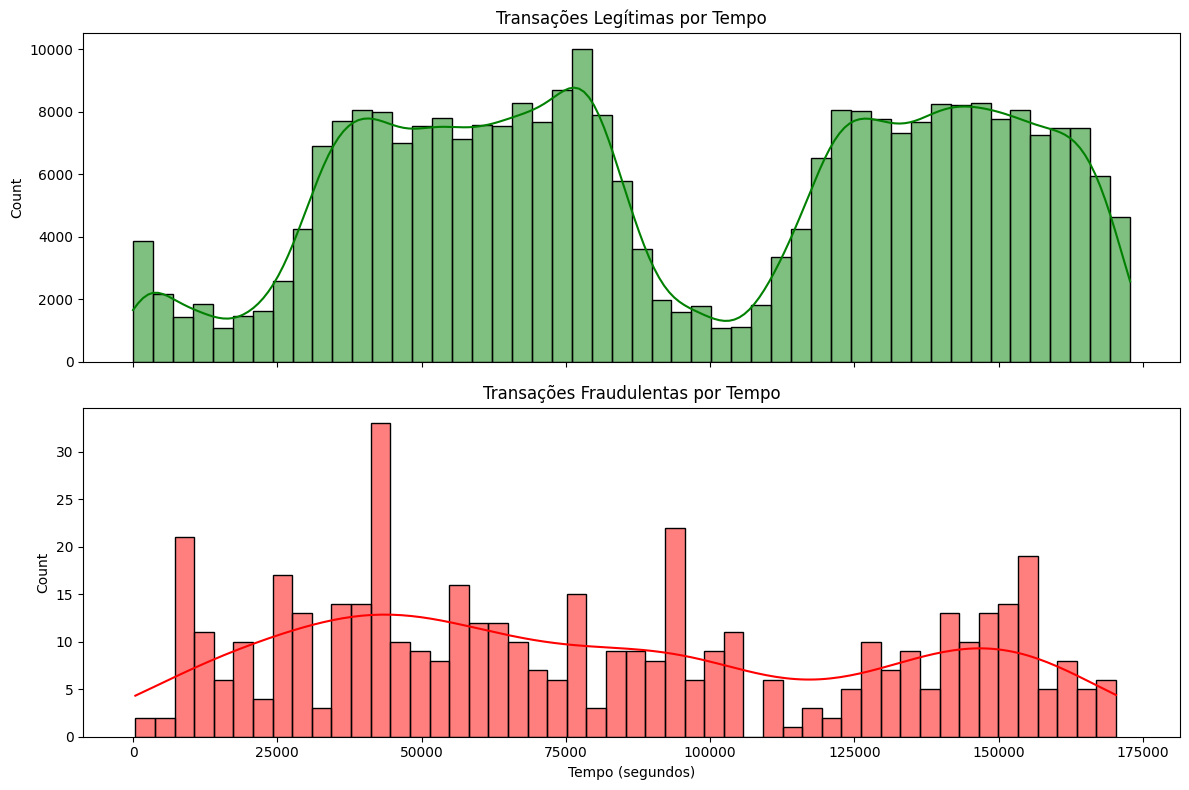

In [33]:
import numpy as np

# 1. Tipo e Estatísticas
print(f"Tipo da coluna Time: {df['Time'].dtype}")
display(df['Time'].describe())

# 2. Correlação específica
corr_time = df[['Time', 'Class']].corr().iloc[0,1]
print(f"\nCorrelação entre Time e Class: {corr_time:.4f}")

# 3. Visualização da Distribuição Temporal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.histplot(df[df['Class'] == 0]['Time'], bins=50, ax=ax1, color='g', kde=True)
ax1.set_title('Transações Legítimas por Tempo')

sns.histplot(df[df['Class'] == 1]['Time'], bins=50, ax=ax2, color='r', kde=True)
ax2.set_title('Transações Fraudulentas por Tempo')

plt.xlabel('Tempo (segundos)')
plt.tight_layout()
plt.show()

### **Análise**: Variável 'Time'

Ao observar os histogramas de distribuição temporal:
- **Transações Legítimas**: Apresentam uma estrutura cíclica clara (provavelmente dia/noite), com vales que representam períodos de sono.
- **Transações Fraudulentas**: Estão distribuídas de forma muito mais uniforme. Não há uma queda tão acentuada durante a 'noite' do dataset, o que indica que a fraude não descansa.
- **Conclusão**: A feature `Time` em sua forma bruta é ruidosa, mas revela que o desvio do padrão de comportamento humano normal (comprar em horários comerciais) é um forte indicativo de fraude.

### 2.1. Engenharia de Atributos: Transformando 'Time' em Horas

Vamos converter os segundos para um formato de 24 horas para identificar padrões de comportamento por período do dia.

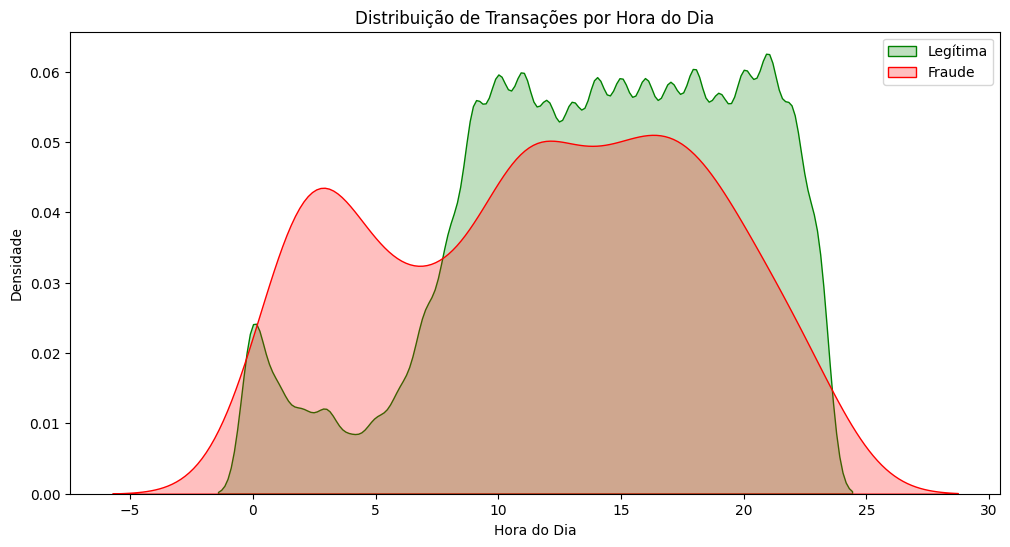

In [34]:
# Converter segundos para horas (0-23)
df['Hour'] = (df['Time'] // 3600) % 24

plt.figure(figsize=(12, 6))
sns.kdeplot(df[df['Class'] == 0]['Hour'], label='Legítima', fill=True, color='g')
sns.kdeplot(df[df['Class'] == 1]['Hour'], label='Fraude', fill=True, color='r')
plt.title('Distribuição de Transações por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Densidade')
plt.legend()
plt.show()

### 2.2 Número total de transações por Hora do Dia

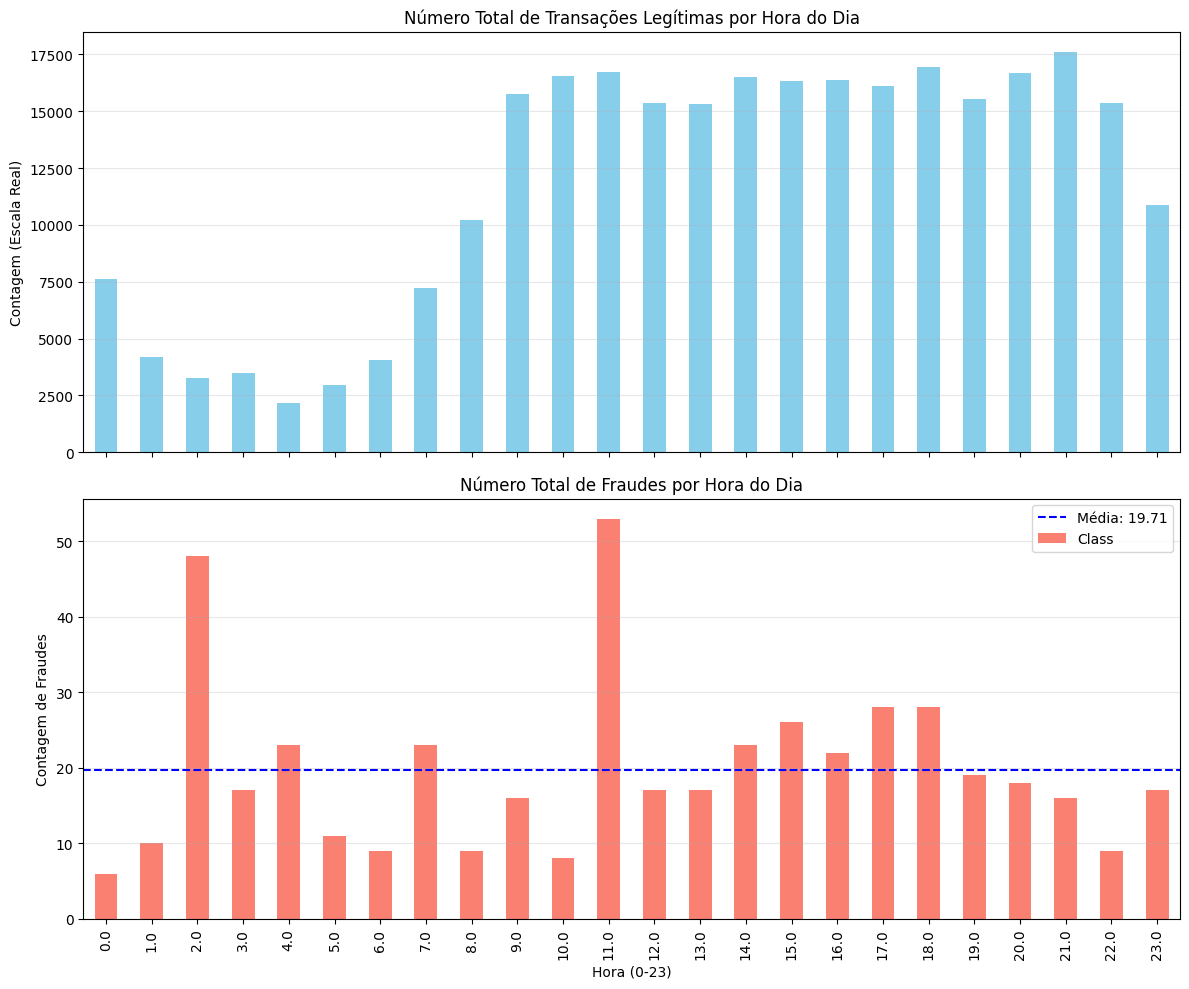

Coluna 'Time' removida com sucesso. Feature 'Hour' preservada.


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Garantir que a coluna Hour existe
if 'Hour' not in df.columns:
    df['Hour'] = (df['Time'] // 3600) % 24

# Agrupando dados
legit_by_hour = df[df['Class'] == 0].groupby('Hour')['Class'].count()
fraud_by_hour = df[df['Class'] == 1].groupby('Hour')['Class'].count()

# Criando a visualização comparativa
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Gráfico 1: Transações Legítimas
legit_by_hour.plot(kind='bar', color='skyblue', ax=ax1)
ax1.set_title('Número Total de Transações Legítimas por Hora do Dia')
ax1.set_ylabel('Contagem (Escala Real)')
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Transações Fraudulentas
fraud_by_hour.plot(kind='bar', color='salmon', ax=ax2)
avg_fraud_per_hour = fraud_by_hour.mean()
ax2.axhline(y=avg_fraud_per_hour, color='blue', linestyle='--', label=f'Média: {avg_fraud_per_hour:.2f}')
ax2.set_title('Número Total de Fraudes por Hora do Dia')
ax2.set_xlabel('Hora (0-23)')
ax2.set_ylabel('Contagem de Fraudes')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Agora que 'Hour' foi extraída e validada, podemos remover a coluna bruta 'Time'
if 'Time' in df.columns:
    df.drop('Time', axis=1, inplace=True)
    print("Coluna 'Time' removida com sucesso. Feature 'Hour' preservada.")

### Análise e Insights - Seção 2

- **Comportamento Temporal**: A feature `Time` original tem correlação linear quase nula (-0.0124), indicando que o tempo bruto não prevê fraude.
- **Padrões por Hora**: Ao transformar em ciclos de 24h, notamos que a média de fraudes é de aproximadamente **19.71 por hora**.
- **Insights de Madrugada**: O gráfico de densidade mostra picos de fraude em horários de menor volume de transações legítimas (madrugada), confirmando que a hora do dia é uma feature mais informativa que o tempo linear.

## 3. Visualização do t-SNE de uma amostra do dataset

**O que será feito:**
Utilizaremos o t-SNE (*t-Distributed Stochastic Neighbor Embedding*), uma técnica de redução de dimensionalidade não-linear, para projetar as features do dataset em um plano bidimensional (2D).

**Por que será feito:**
Como o dataset possui muitas dimensões, o t-SNE permite visualizar se as transações fraudulentas formam agrupamentos distintos das legítimas, validando visualmente a separabilidade dos dados — complementando as análises de correlação e distribuição das seções anteriores.

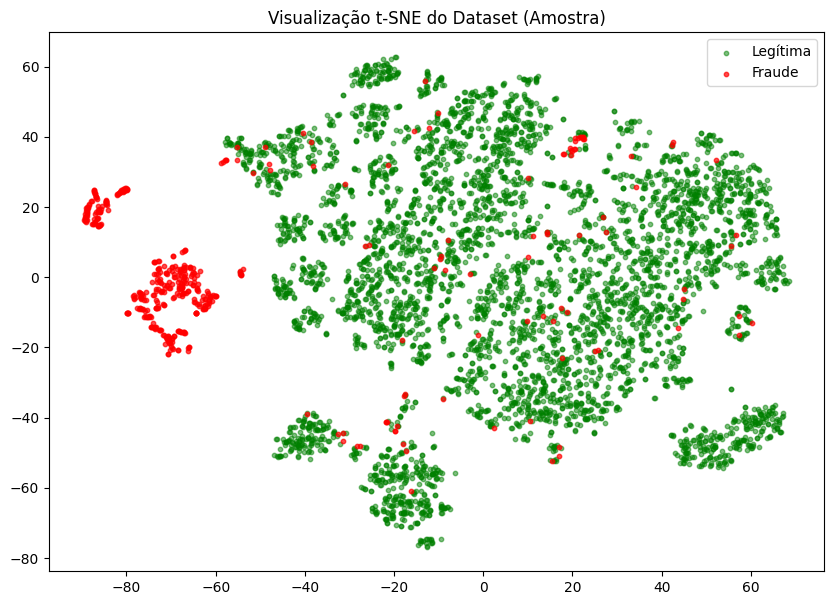

In [36]:
from sklearn.manifold import TSNE

# Amostrar os dados para não travar o kernel (ex: 5000 normais + todas as fraudes)
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0].sample(5000, random_state=42)
df_tsne = pd.concat([fraud, legit])

X_tsne = df_tsne.drop(['Class'], axis=1)
y_tsne = df_tsne['Class']

tsne = TSNE(n_components=2, random_state=42)
X_transformed = tsne.fit_transform(X_tsne)

plt.figure(figsize=(10, 7))
plt.scatter(X_transformed[y_tsne == 0, 0], X_transformed[y_tsne == 0, 1], label='Legítima', alpha=0.5, c='g', s=10)
plt.scatter(X_transformed[y_tsne == 1, 0], X_transformed[y_tsne == 1, 1], label='Fraude', alpha=0.7, c='r', s=10)
plt.title('Visualização t-SNE do Dataset (Amostra)')
plt.legend()
plt.show()

### Análise e Insights - Seção 3 (t-SNE)

- **Agrupamento**: O t-SNE revela que, mesmo em apenas duas dimensões, a maioria das transações fraudulentas (pontos vermelhos) tende a se agrupar ou se afastar da massa principal de transações legítimas.
- **Separabilidade**: Isso indica que o problema é viável para modelos de classificação, pois existe uma distinção estatística e espacial entre as classes, apesar do desbalanceamento extremo.